In [1]:
install.packages(c("readxl","dplyr","tidyr","stringr","naniar","visdat",
                   "ggplot2","psych","e1071","GPArotation","corrplot",
                   "tidyverse","lavaan","janitor","semTools",
                   "BifactorIndicesCalculator", "EFAtools"), dependencies = TRUE, Ncpus = 1)

Instalando pacotes em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)

Warning message:
"dependências 'graph', 'Rgraphviz' não estão disponíveis"
instalando as dependências 'proto', 'VIM', 'gsubfn', 'wakefield', 'simputation', 'imputeTS', 'munsell', 'profvis', 'Rcsdp', 'MplusAutomation' também




package 'proto' successfully unpacked and MD5 sums checked
package 'VIM' successfully unpacked and MD5 sums checked
package 'gsubfn' successfully unpacked and MD5 sums checked
package 'wakefield' successfully unpacked and MD5 sums checked
package 'simputation' successfully unpacked and MD5 sums checked
package 'imputeTS' successfully unpacked and MD5 sums checked
package 'munsell' successfully unpacked and MD5 sums checked
package 'profvis' successfully unpacked and MD5 sums checked
package 'Rcsdp' successfully unpacked and MD5 sums checked
package 'MplusAutomation' successfully unpacked and MD5 sums checked
package 'readxl' successfully unpacked and MD5 sums checked
package 'dplyr' successfully unpacked and MD5 sums checked
package 'tidyr' successfully unpacked and MD5 sums checked
package 'stringr' successfully unpacked and MD5 sums checked
package 'naniar' successfully unpacked and MD5 sums checked
package 'visdat' successfully unpacked and MD5 sums checked
package 'ggplot2' success

In [2]:
pacotes <- c(
  "readxl", "dplyr", "tidyr", "stringr", "naniar", "visdat",
  "ggplot2", "psych", "e1071", "GPArotation", "corrplot",
  "tidyverse", "lavaan", "janitor", "semTools",
  "BifactorIndicesCalculator", "EFAtools"
)

lapply(pacotes, library, character.only = TRUE)


Anexando pacote: 'dplyr'


Os seguintes objetos são mascarados por 'package:stats':

    filter, lag


Os seguintes objetos são mascarados por 'package:base':

    intersect, setdiff, setequal, union



Anexando pacote: 'psych'


Os seguintes objetos são mascarados por 'package:ggplot2':

    %+%, alpha



Anexando pacote: 'e1071'


O seguinte objeto é mascarado por 'package:ggplot2':

    element



Anexando pacote: 'GPArotation'


Os seguintes objetos são mascarados por 'package:psych':

    equamax, varimin


corrplot 0.95 loaded



ERROR: Error: carregamento do pacote ou namespace falhou para 'tidyverse':
 .onAttach falhou em attachNamespace() para 'tidyverse', detalhes:
  chamada: NULL
  erro: carregamento do pacote ou namespace falhou para 'lubridate' in loadNamespace(j <- i[[1L]], c(lib.loc, .libPaths()), versionCheck = vI[[j]]):
 não há nenhum pacote chamado 'timechange'


In [4]:
# =========================================================
# 1. IMPORTAR BASE
# =========================================================

onet <- read.csv(
  "onet-v6.txt",
  check.names = FALSE
)

# visualizar estrutura
glimpse(onet)

Rows: 1,084,860
Columns: 14
$ `O*NET-SOC Code`    <chr> "11-1011.00", "11-1011.00", "11-1011.00", "11-1011…
$ Title               <chr> "Chief Executives", "Chief Executives", "Chief Exe…
$ `Element ID`        <chr> "1.A.1.a.1", "1.A.1.a.1", "1.A.1.a.2", "1.A.1.a.2"…
$ `Element Name`      <chr> "Oral Comprehension", "Oral Comprehension", "Writt…
$ Date                <chr> "07/2014", "07/2014", "07/2014", "07/2014", "07/20…
$ `Scale ID`          <chr> "IM", "LV", "IM", "LV", "IM", "LV", "IM", "LV", "I…
$ `Scale Name`        <chr> "Importance", "Level", "Importance", "Level", "Imp…
$ `Data Value`        <dbl> 4.50, 4.88, 4.25, 4.62, 4.38, 5.00, 4.12, 4.62, 3.…
$ Type                <chr> "Abilities", "Abilities", "Abilities", "Abilities"…
$ Version             <dbl> 22.1, 22.1, 22.1, 22.1, 22.1, 22.1, 22.1, 22.1, 22…
$ `Version Year`      <int> 2017, 2017, 2017, 2017, 2017, 2017, 2017, 2017, 20…
$ Quarter             <chr> "Q4", "Q4", "Q4", "Q4", "Q4", "Q4", "Q4", "Q4", "Q…
$ Year      

### Tratamento dos Dados

Inicialmente, foi realizada a importação da base de dados da ONET contendo informações ocupacionais longitudinais entre os anos de 2016 e 2026. Em seguida, foi criada uma variável denominada “Element and Scale”, resultante da combinação entre o nome do elemento ocupacional (“Element Name”) e o tipo de escala associado (“Scale Name”). Esse procedimento permitiu identificar de forma única cada atributo ocupacional mensurado pela ONET, distinguindo, por exemplo, medidas de importância, nível ou impacto referentes à mesma skill ou característica ocupacional.

Posteriormente, os valores da variável “Data Value” foram padronizados por meio da transformação em escore-z dentro de cada grupo de “Scale ID”. Essa etapa teve como objetivo tornar comparáveis variáveis originalmente medidas em escalas distintas, eliminando diferenças de magnitude entre métricas heterogêneas e permitindo futuras análises multivariadas, como PCA, CFA ou construção de índices sintéticos.

In [5]:
# =========================================================
# 2. AGRUPAR SCALE ID
# =========================================================

onet <- onet %>%
  group_by(`Scale ID`) %>%
  mutate(
    z_Data_Value = as.numeric(scale(`Data Value`))
  ) %>%
  ungroup()

In [6]:
# =========================================================
# 3. Z-SCORE DENTRO DE CADA SCALE ID
# =========================================================

onet <- onet %>%
  group_by(`Scale ID`) %>%
  mutate(
    z_Data_Value = as.numeric(scale(`Data Value`))
  ) %>%
  ungroup()

# verificar
summary(onet$z_Data_Value)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-1.86211 -0.72075  0.08133  0.00000  0.69091  3.25147 

## Pipeline

### Matriz Longitudinal

In [7]:
# =========================================================
# ETAPA 1
# PADRONIZAR ANO TEMPORAL
# =========================================================

onet <- onet %>%
  mutate(
    Version_Year = as.numeric(`Version Year`)
  )

# verificar anos disponíveis
sort(unique(onet$Version_Year))

[1] 2017 2019 2021 2023 2025

In [8]:
onet <- onet %>%
  filter(
    if_all(
      everything(),
      ~ !is.na(.) & . != ""
    )
  )

In [9]:
nrow(onet)

[1] 1084860

In [10]:
# =========================================================
# ETAPA 2
# OCUPAÇÕES PRESENTES EM TODOS OS VERSION YEAR
# =========================================================

anos_disponiveis <- sort(unique(onet$Version_Year))

occ_long <- onet %>%
  filter(Version_Year %in% anos_disponiveis) %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    n_years = n_distinct(Version_Year),
    .groups = "drop"
  ) %>%
  filter(
    n_years == length(anos_disponiveis)
  )

sample_long <- onet %>%
  filter(
    `O*NET-SOC Code` %in%
      occ_long$`O*NET-SOC Code`
  )

# tamanho da amostra
cat(
  "\nSample longitudinal:",
  nrow(sample_long),
  "linhas\n"
)


Sample longitudinal: 959099 linhas


In [11]:
# =========================================================
# ETAPA 3
# FUNÇÃO DE ANÁLISE DE MISSING
# =========================================================

missing_analysis <- function(data,
                             sample_name){

  cat("\n===================================")
  cat("\n", sample_name)
  cat("\n===================================\n")

  # -------------------------------------------------------
  # identificar duplicatas
  # -------------------------------------------------------

  duplicates <- data %>%
    group_by(
      `O*NET-SOC Code`,
      Title,
      Version_Year,
      `Element and Scale`
    ) %>%
    summarise(
      n = n(),
      .groups = "drop"
    ) %>%
    filter(n > 1)

  cat(
    "\nNúmero de combinações duplicadas:",
    nrow(duplicates),
    "\n"
  )

  # -------------------------------------------------------
  # transformar em wide
  # média em caso de duplicidade
  # -------------------------------------------------------

  data_wide <- data %>%
    # filter(`Element and Scale` != "") %>% # Adicionado para remover strings vazias
    select(
      `O*NET-SOC Code`,
      Title,
      Version_Year,
      `Element and Scale`,
      z_Data_Value
    ) %>%
    pivot_wider(
      names_from = `Element and Scale`,
      values_from = z_Data_Value,
      values_fn = mean
    )

  # -------------------------------------------------------
  # missing por variável
  # -------------------------------------------------------

  missing_var <- data_wide %>%
    summarise(
      across(
        everything(),
        ~mean(is.na(.))*100
      )
    ) %>%
    pivot_longer(
      cols = everything(),
      names_to = "variavel",
      values_to = "perc_missing"
    ) %>%
    arrange(desc(perc_missing))

  print(head(missing_var, 30))

  # -------------------------------------------------------
  # missing global
  # -------------------------------------------------------

  global_missing <- round(
    mean(is.na(data_wide)) * 100,
    2
  )

  cat(
    "\nMissing global:",
    global_missing,
    "%\n"
  )

  # -------------------------------------------------------
  # missing por ano
  # -------------------------------------------------------

  missing_year <- data_wide %>%
    group_by(Version_Year) %>%
    summarise(
      perc_missing = round(
        mean(
          is.na(across(everything()))
        ) * 100,
        2
      ),
      .groups = "drop"
    )

  print(missing_year)

  # -------------------------------------------------------
  # missing por tipo
  # -------------------------------------------------------

  missing_type <- data %>%
    group_by(Type) %>%
    summarise(
      perc_missing = round(
        mean(
          is.na(z_Data_Value)
        ) * 100,
        2
      ),
      n = n(),
      .groups = "drop"
    )

  print(missing_type)

    # -------------------------------------------------------
    # visualização (amostra reduzida)
    # -------------------------------------------------------

    data_wide %>%
      slice_sample(n = 1000) %>%
      vis_miss(warn_large_data = FALSE)

  # -------------------------------------------------------
  # classificação das variáveis
  # -------------------------------------------------------

  classified_vars <- missing_var %>%
    mutate(
      categoria = case_when(

        perc_missing <= 5 ~
          "core_stable",

        perc_missing > 5 &
          perc_missing <= 30 ~
          "transitional",

        perc_missing > 30 &
          perc_missing <= 70 ~
          "emergent",

        perc_missing > 70 ~
          "sparse"
      )
    )

  cat("\nResumo das categorias:\n")
  print(table(classified_vars$categoria))

  # -------------------------------------------------------
  # gráfico
  # -------------------------------------------------------

  ggplot(
    classified_vars,
    aes(x = categoria)
  ) +
    geom_bar() +
    theme_minimal() +
    labs(
      title = paste(
        "Classificação das variáveis -",
        sample_name
      )
    ) %>%
    print()

  return(list(

    data_wide = data_wide,

    missing_var = missing_var,

    missing_year = missing_year,

    missing_type = missing_type,

    classified_vars = classified_vars
  ))
}

In [12]:
# =========================================================
# ETAPA 4
# RODAR ANÁLISE
# =========================================================

miss_long <- missing_analysis(
  sample_long,
  "LONGITUDINAL SAMPLE"
)


 LONGITUDINAL SAMPLE

Número de combinações duplicadas: 6089 
# A tibble: 30 × 2
   variavel                                                     perc_missing
   <chr>                                                               <dbl>
 1 Clerical - Level                                                     62.2
 2 Interacting With Computers - Level                                   62  
 3 Communicating with Persons Outside Organization - Level              60.9
 4 Inspecting Equipment, Structures, or Material - Level                60.7
 5 Provide Consultation and Advice to Others - Level                    60.5
 6 Operation Monitoring - Level                                         60.1
 7 Judging the Qualities of Things, Services, or People - Level         60.1
 8 Monitor Processes, Materials, or Surroundings - Level                60.1
 9 Clerical - Importance                                                60  
10 Operation Monitoring - Importance                                   

In [13]:
# =========================================================
# ETAPA 5
# VARIÁVEIS UTILIZÁVEIS
# =========================================================

valid_vars <- miss_long$classified_vars %>%
  filter(
    categoria != "sparse"
  ) %>%
  pull(variavel)

length(valid_vars)

[1] 339

In [14]:
# =========================================================
# ETAPA 6
# MATRIZ FINAL PARA EFA/CFA
# =========================================================

panel_wide <- miss_long$data_wide %>%
  select(
    `O*NET-SOC Code`,
    Title,
    Version_Year,
    any_of(valid_vars)
  )

# dimensões finais
dim(panel_wide)

# missing final
mean(is.na(panel_wide))*100

[1] 3050  339

[1] 6.943276

### Diagnóstico Longitudinal

In [15]:
# =========================================================
# ETAPA 2.1
# DISTRIBUIÇÃO
# =========================================================

# ---------------------------------------------------------
# matriz apenas numérica
# ---------------------------------------------------------

efa_data <- panel_wide %>%
  select(
    -`O*NET-SOC Code`,
    -Title,
    -Version_Year
  )

# ---------------------------------------------------------
# skewness e kurtosis
# ---------------------------------------------------------

distribution_stats <- tibble(
  variavel = names(efa_data),

  skewness = sapply(
    efa_data,
    e1071::skewness,
    na.rm = TRUE
  ),

  kurtosis = sapply(
    efa_data,
    e1071::kurtosis,
    na.rm = TRUE
  )
)

# visualizar
head(distribution_stats)

# ---------------------------------------------------------
# resumo distribuição
# ---------------------------------------------------------

summary(distribution_stats$skewness)
summary(distribution_stats$kurtosis)

variavel,skewness,kurtosis
<chr>,<dbl>,<dbl>
Clerical - Level,0.08440983,-0.6440795
Interacting With Computers - Level,-0.29245101,-0.1440862
Communicating with Persons Outside Organization - Level,-0.06231120,-0.6601409
"Inspecting Equipment, Structures, or Material - Level",-0.24463105,-0.5335300
Provide Consultation and Advice to Others - Level,0.37624741,-0.5762811
Operation Monitoring - Level,-0.19215381,-0.7643286


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-0.94107 -0.06213  0.23293  0.37652  0.71887  3.97786 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-1.4292 -0.6474 -0.2383  0.3276  0.3511 28.1704 

Warning message:
"Removed 16669 rows containing non-finite outside the scale range (`stat_density()`)."


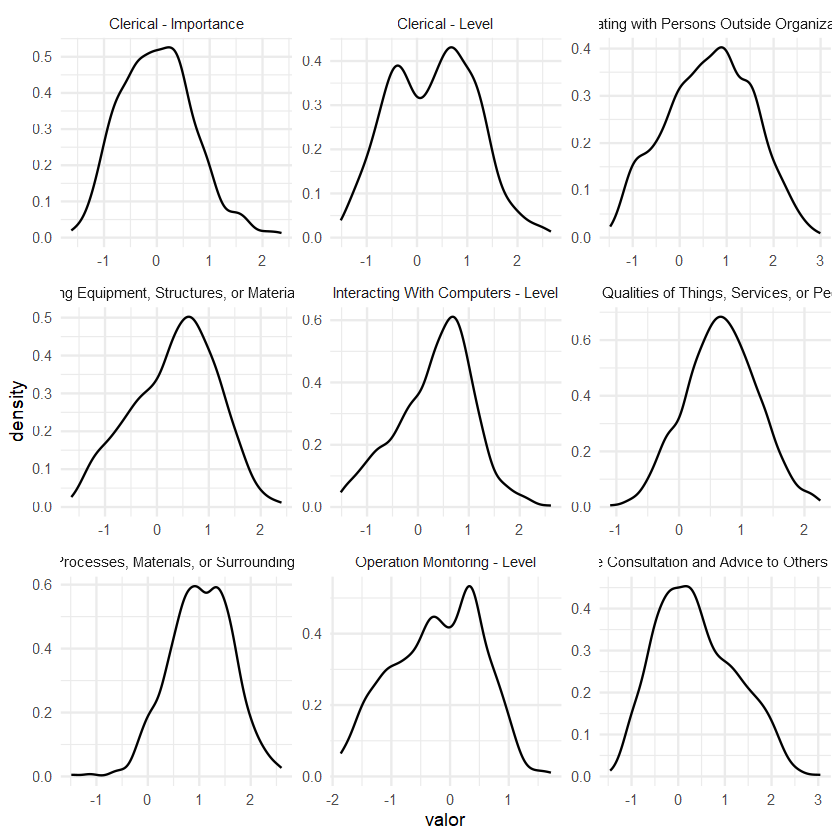

In [16]:
# =========================================================
# DENSITY PLOTS
# =========================================================

# ---------------------------------------------------------
# selecionar algumas variáveis
# ---------------------------------------------------------

selected_vars <- names(efa_data)[1:9]

density_data <- panel_wide %>%
  select(
    Version_Year,
    all_of(selected_vars)
  ) %>%
  pivot_longer(
    cols = -Version_Year,
    names_to = "variavel",
    values_to = "valor"
  )

# ---------------------------------------------------------
# density plots
# ---------------------------------------------------------

ggplot(
  density_data,
  aes(x = valor)
) +
  geom_density() +
  facet_wrap(
    ~variavel,
    scales = "free"
  ) +
  theme_minimal()

Warning message:
"Removed 16669 rows containing non-finite outside the scale range (`stat_density()`)."


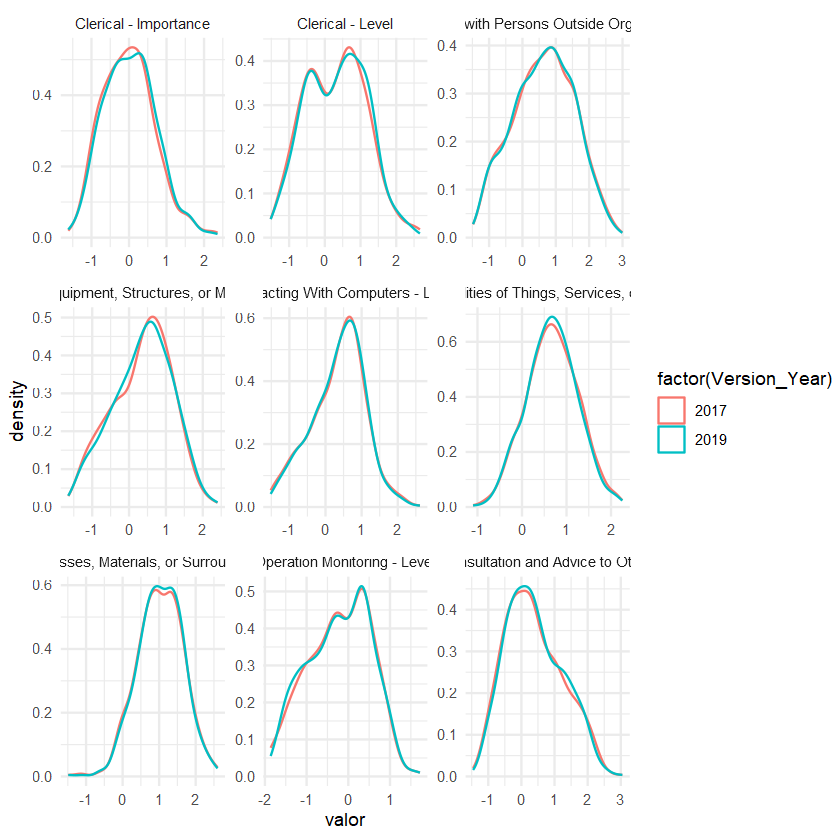

In [17]:
# =========================================================
# DISTRIBUIÇÃO POR ANO
# =========================================================

ggplot(
  density_data,
  aes(
    x = valor,
    color = factor(Version_Year)
  )
) +
  geom_density() +
  facet_wrap(
    ~variavel,
    scales = "free"
  ) +
  theme_minimal()

In [18]:
# =========================================================
# DISTRIBUIÇÃO POR TYPE
# =========================================================

type_distribution <- sample_long %>%
  group_by(Type) %>%
  summarise(
    media = mean(
      z_Data_Value,
      na.rm = TRUE
    ),
    sd = sd(
      z_Data_Value,
      na.rm = TRUE
    ),
    skewness = e1071::skewness(
      z_Data_Value,
      na.rm = TRUE
    ),
    kurtosis = e1071::kurtosis(
      z_Data_Value,
      na.rm = TRUE
    ),
    .groups = "drop"
  )

type_distribution

Type,media,sd,skewness,kurtosis
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Abilities,-0.1952908,0.9500309,-0.2014174,-0.7916641
Knowledge,-0.2856830,0.9961904,0.6064374,-0.3240801
Skills,-0.1185733,0.9212085,-0.2229675,-0.7232817
Work Activities,0.5363431,0.9142254,-0.1474497,-0.5605295


In [19]:
# =========================================================
# ETAPA 2.2
# MATRIZ DE CORRELAÇÃO
# =========================================================

# ---------------------------------------------------------
# correlação spearman
# ---------------------------------------------------------

cor_mat <- cor(
  efa_data,
  method = "spearman",
  use = "pairwise.complete.obs"
)

# visualizar parte da matriz
# cor_mat[1:10, 1:10]

# ---------------------------------------------------------
# mapa de correlação
# ---------------------------------------------------------

#corrplot(
#  cor_mat[1:40, 1:40],
#  method = "color",
#  tl.cex = .6
#)

In [20]:
# =========================================================
# REMOVER VARIÁVEIS PROBLEMÁTICAS
# =========================================================

# remover identificadores
efa_data <- panel_wide %>%
  select(where(is.numeric))

# ---------------------------------------------------------
# remover variância zero
# ---------------------------------------------------------

vars_ok <- efa_data %>%
  select(where(~ sd(., na.rm = TRUE) > 0))

# ---------------------------------------------------------
# remover colunas com NA
# ---------------------------------------------------------

vars_ok <- vars_ok %>%
  select(where(~ !any(is.na(.))))

# ---------------------------------------------------------
# verificar dimensões
# ---------------------------------------------------------

dim(vars_ok)

[1] 3050  180

In [21]:
# =========================================================
# MATRIZ DE CORRELAÇÃO
# =========================================================

cor_mat <- cor(vars_ok)

In [22]:
# =========================================================
# ETAPA 2.3
# KMO LONGITUDINAL
# =========================================================

# ---------------------------------------------------------
# KMO GLOBAL
# ---------------------------------------------------------

kmo_global <- psych::KMO(cor_mat)

kmo_global

Kaiser-Meyer-Olkin factor adequacy
Call: psych::KMO(r = cor_mat)
Overall MSA =  0.98
MSA for each item = 
                                                                                Version_Year 
                                                                                        0.43 
                                                             Oral Comprehension - Importance 
                                                                                        0.99 
                                                                  Oral Comprehension - Level 
                                                                                        0.99 
                                                          Written Comprehension - Importance 
                                                                                        0.99 
                                                               Written Comprehension - Level 
                                                

In [23]:
# =========================================================
# FUNÇÃO PARA REMOVER CORRELAÇÕES ALTAS
# =========================================================

remove_high_cor <- function(cor_mat, cutoff = 0.95){

  cor_mat_abs <- abs(cor_mat)

  diag(cor_mat_abs) <- 0

  remove_vars <- c()

  while(max(cor_mat_abs) > cutoff){

    idx <- which(
      cor_mat_abs == max(cor_mat_abs),
      arr.ind = TRUE
    )[1, ]

    var1 <- colnames(cor_mat_abs)[idx[1]]
    var2 <- colnames(cor_mat_abs)[idx[2]]

    mean1 <- mean(cor_mat_abs[var1, ])
    mean2 <- mean(cor_mat_abs[var2, ])

    remove_var <- ifelse(mean1 > mean2, var1, var2)

    remove_vars <- c(remove_vars, remove_var)

    cor_mat_abs <- cor_mat_abs[
      !rownames(cor_mat_abs) %in% remove_var,
      !colnames(cor_mat_abs) %in% remove_var
    ]
  }

  return(unique(remove_vars))
}

# =========================================================
# KMO POR ANO
# =========================================================

years <- unique(panel_wide$Version_Year)

kmo_years <- list()

for(y in years){

  cat("\n====================\n")
  cat("ANO:", y, "\n")
  cat("====================\n")

  temp <- panel_wide %>%
    filter(
      Version_Year == y
    ) %>%
    select(
      -`O*NET-SOC Code`,
      -Title,
      -Version_Year
    ) %>%

    # remover colunas totalmente NA
    select(
      where(~ !all(is.na(.)))
    ) %>%

    # remover variância zero
    select(
      where(~ {
        s <- sd(., na.rm = TRUE)
        !is.na(s) && s > 0
      })
    )

  # -------------------------------------------------------
  # imputação simples
  # -------------------------------------------------------

  temp <- temp %>%
    mutate(
      across(
        everything(),
        ~ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .
        )
      )
    )

  # -------------------------------------------------------
  # correlação
  # -------------------------------------------------------

  cor_temp <- cor(
    temp,
    method = "spearman"
  )

  # -------------------------------------------------------
  # remover correlação extrema
  # -------------------------------------------------------

  vars_remove <- remove_high_cor(
    cor_temp,
    cutoff = 0.95
  )

  if(length(vars_remove) > 0){

    temp <- temp %>%
      select(
        -all_of(vars_remove)
      )
  }

  cat("Variáveis removidas:", length(vars_remove), "\n")
  cat("Variáveis finais:", ncol(temp), "\n")

  # -------------------------------------------------------
  # nova matriz
  # -------------------------------------------------------

  cor_temp <- cor(
    temp,
    method = "spearman"
  )

  # -------------------------------------------------------
  # KMO
  # -------------------------------------------------------

  kmo_temp <- psych::KMO(cor_temp)

  kmo_years[[as.character(y)]] <- kmo_temp$MSA

  print(kmo_temp$MSA)
}


ANO: 2017 
Variáveis removidas: 43 
Variáveis finais: 277 
[1] 0.9719898

ANO: 2019 
Variáveis removidas: 48 
Variáveis finais: 272 
[1] 0.9722939

ANO: 2021 
Variáveis removidas: 48 
Variáveis finais: 272 
[1] 0.9716638

ANO: 2023 
Variáveis removidas: 48 
Variáveis finais: 272 
[1] 0.9711327

ANO: 2025 
Variáveis removidas: 51 
Variáveis finais: 269 
[1] 0.9713567


In [24]:
# =========================================================
# KMO POR TYPE
# =========================================================

types <- unique(sample_long$Type)

kmo_types <- list()

for(t in types){

  cat("\n====================\n")
  cat("TYPE:", t, "\n")
  cat("====================\n")

  vars_type <- sample_long %>%
    filter(Type == t) %>%
    pull(`Element and Scale`) %>%
    unique()

  vars_type <- intersect(
    vars_type,
    names(efa_data)
  )

  if(length(vars_type) > 2){

    temp <- efa_data %>%
      select(all_of(vars_type)) %>%

      # remover colunas totalmente NA
      select(
        where(~ !all(is.na(.)))
      ) %>%

      # remover variância zero
      select(
        where(~ {
          s <- sd(., na.rm = TRUE)
          !is.na(s) && s > 0
        })
      )

    # -----------------------------------------------------
    # imputação simples
    # -----------------------------------------------------

    temp <- temp %>%
      mutate(
        across(
          everything(),
          ~ifelse(
            is.na(.),
            median(., na.rm = TRUE),
            .
          )
        )
      )

    # -----------------------------------------------------
    # correlação
    # -----------------------------------------------------

    cor_temp <- cor(
      temp,
      method = "spearman"
    )

    # -----------------------------------------------------
    # remover colinearidade extrema
    # -----------------------------------------------------

    vars_remove <- remove_high_cor(
      cor_temp,
      cutoff = 0.95
    )

    if(length(vars_remove) > 0){

      temp <- temp %>%
        select(
          -all_of(vars_remove)
        )
    }

    cat("Variáveis removidas:", length(vars_remove), "\n")
    cat("Variáveis finais:", ncol(temp), "\n")

    # -----------------------------------------------------
    # nova correlação
    # -----------------------------------------------------

    cor_temp <- cor(
      temp,
      method = "spearman"
    )

    # -----------------------------------------------------
    # KMO
    # -----------------------------------------------------

    kmo_temp <- psych::KMO(cor_temp)

    kmo_types[[t]] <- kmo_temp$MSA

    print(kmo_temp$MSA)
  }
}

kmo_types


TYPE: Abilities 
Variáveis removidas: 29 
Variáveis finais: 75 
[1] 0.9732826

TYPE: Knowledge 
Variáveis removidas: 0 
Variáveis finais: 68 
[1] 0.9060808

TYPE: Skills 
Variáveis removidas: 16 
Variáveis finais: 56 
[1] 0.9708138

TYPE: Work Activities 
Variáveis removidas: 0 
Variáveis finais: 94 
[1] 0.9532192


$Abilities
[1] 0.9732826

$Knowledge
[1] 0.9060808

$Skills
[1] 0.9708138

$`Work Activities`
[1] 0.9532192

In [25]:
# =========================================================
# ETAPA 2.4
# BARTLETT LONGITUDINAL
# =========================================================

# ---------------------------------------------------------
# BARTLETT GLOBAL
# ---------------------------------------------------------

bart_global <- cortest.bartlett(
  cor_mat,
  n = nrow(efa_data)
)

bart_global

$chisq
[1] 1009025

$p.value
[1] 0

$df
[1] 16110

In [26]:
# =========================================================
# BARTLETT POR ANO
# =========================================================

bart_years <- list()

for(y in years){

  temp <- panel_wide %>%
    filter(
      Version_Year == y
    ) %>%
    select(
      -`O*NET-SOC Code`,
      -Title,
      -Version_Year
    ) %>%

    select(
      where(~ !all(is.na(.)))
    ) %>%

    select(
      where(~ {
        s <- sd(., na.rm = TRUE)
        !is.na(s) && s > 0
      })
    )

  # imputação
  temp <- temp %>%
    mutate(
      across(
        everything(),
        ~ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .
        )
      )
    )

  # correlação
  cor_temp <- cor(
    temp,
    method = "spearman"
  )

  # remover colinearidade extrema
  vars_remove <- remove_high_cor(
    cor_temp,
    cutoff = 0.95
  )

  if(length(vars_remove) > 0){

    temp <- temp %>%
      select(
        -all_of(vars_remove)
      )
  }

  # nova correlação
  cor_temp <- cor(
    temp,
    method = "spearman"
  )

  bart_temp <- cortest.bartlett(
    cor_temp,
    n = nrow(temp)
  )

  bart_years[[as.character(y)]] <- bart_temp
}

bart_years

$`2017`
$`2017`$chisq
[1] 286521.6

$`2017`$p.value
[1] 0

$`2017`$df
[1] 38226


$`2019`
$`2019`$chisq
[1] 279316.5

$`2019`$p.value
[1] 0

$`2019`$df
[1] 36856


$`2021`
$`2021`$chisq
[1] 277855.7

$`2021`$p.value
[1] 0

$`2021`$df
[1] 36856


$`2023`
$`2023`$chisq
[1] 276613.4

$`2023`$p.value
[1] 0

$`2023`$df
[1] 36856


$`2025`
$`2025`$chisq
[1] 270700.4

$`2025`$p.value
[1] 0

$`2025`$df
[1] 36046

In [27]:
# =========================================================
# ETAPA 2.5
# MSA ITEM-LEVEL
# =========================================================

msa_items <- tibble(

  variavel = names(kmo_global$MSAi),

  msa = as.numeric(kmo_global$MSAi)

)

# ---------------------------------------------------------
# classificar MSA
# ---------------------------------------------------------

msa_items <- msa_items %>%
  mutate(
    classificacao = case_when(

      msa >= .90 ~ "marvelous",

      msa >= .80 ~ "meritorious",

      msa >= .70 ~ "middling",

      msa >= .60 ~ "mediocre",

      msa >= .50 ~ "miserable",

      msa < .50 ~ "remove"
    )
  ) %>%
  arrange(msa)

# visualizar piores variáveis
head(msa_items, 30)

variavel,msa,classificacao
<chr>,<dbl>,<chr>
Version_Year,0.4251440,remove
Sales and Marketing - Importance,0.8790703,meritorious
Design - Importance,0.9214075,marvelous
Telecommunications - Importance,0.9243300,marvelous
Public Safety and Security - Importance,0.9341767,marvelous
Selective Attention - Importance,0.9348159,marvelous
Far Vision - Level,0.9364473,marvelous
Far Vision - Importance,0.9368071,marvelous
Assisting and Caring for Others - Importance,0.9383976,marvelous


In [28]:
# =========================================================
# MATRIZ FINAL PARA EFA LONGITUDINAL
# =========================================================

efa_final <- panel_wide

# ---------------------------------------------------------
# identificar variáveis numéricas da EFA
# ---------------------------------------------------------

vars_efa <- efa_final %>%

  select(where(is.numeric)) %>%

  select(-Version_Year) %>%

  names()

# ---------------------------------------------------------
# remover variância zero
# ---------------------------------------------------------

vars_efa <- vars_efa[
  sapply(
    efa_final[vars_efa],
    function(x){

      s <- sd(x, na.rm = TRUE)

      !is.na(s) && s > 0
    }
  )
]

# ---------------------------------------------------------
# imputação simples
# ---------------------------------------------------------

efa_final[vars_efa] <- lapply(

  efa_final[vars_efa],

  function(x){

    x[is.na(x)] <- median(
      x,
      na.rm = TRUE
    )

    x
  }
)

# ---------------------------------------------------------
# correlação Spearman
# ---------------------------------------------------------

cor_final <- cor(

  efa_final[vars_efa],

  method = "spearman"
)

# ---------------------------------------------------------
# remover correlação extrema
# ---------------------------------------------------------

vars_remove_cor <- remove_high_cor(

  cor_final,

  cutoff = 0.95
)

vars_efa <- setdiff(
  vars_efa,
  vars_remove_cor
)

# ---------------------------------------------------------
# KMO
# ---------------------------------------------------------

kmo_final <- KMO(

  cor(
    efa_final[vars_efa],
    method = "spearman"
  )
)

# ---------------------------------------------------------
# remover MSA baixo (opcional)
# ---------------------------------------------------------

msa_items <- tibble(

  variavel = names(kmo_final$MSAi),

  msa = as.numeric(
    kmo_final$MSAi
  )
)

# remove_vars <- msa_items %>%
#   filter(msa < .50) %>%
#   pull(variavel)

# vars_efa <- setdiff(
#   vars_efa,
#   remove_vars
# )

# ---------------------------------------------------------
# BASE FINAL
# ---------------------------------------------------------

efa_final <- efa_final %>%

  select(
    `O*NET-SOC Code`,
    Title,
    Version_Year,
    all_of(vars_efa)
  )

# ---------------------------------------------------------
# VERIFICAÇÃO
# ---------------------------------------------------------

cat("Observações:", nrow(efa_final), "\n")
cat("Variáveis EFA:", length(vars_efa), "\n")

Observações: 3050 
Variáveis EFA: 287 


### Testes de Adequação Fatorial

In [29]:
# =========================================================
# PREPARAR BASE
# =========================================================

efa_data <- efa_final

# verificar
dim(efa_data)

# anos disponíveis
anos <- sort(unique(panel_wide$Version_Year))

anos

[1] 3050  290

[1] 2017 2019 2021 2023 2025

In [30]:
# =========================================================
# GARANTIR FORMATO
# =========================================================

efa_final <- as_tibble(efa_final)

# verificar
glimpse(efa_final)

Rows: 3,050
Columns: 290
$ `O*NET-SOC Code`                                                                               <chr> …
$ Title                                                                                          <chr> …
$ Version_Year                                                                                   <dbl> …
$ `Clerical - Level`                                                                             <dbl> …
$ `Interacting With Computers - Level`                                                           <dbl> …
$ `Communicating with Persons Outside Organization - Level`                                      <dbl> …
$ `Inspecting Equipment, Structures, or Material - Level`                                        <dbl> …
$ `Provide Consultation and Advice to Others - Level`                                            <dbl> …
$ `Operation Monitoring - Level`                                                                 <dbl> …
$ `Judging the Qualities of Th

In [31]:
run_parallel <- function(data, ano){

  cat("\n====================================\n")
  cat("PARALLEL ANALYSIS:", ano, "\n")
  cat("====================================\n")

  # -------------------------------------------------------
  # remover colunas totalmente NA
  # -------------------------------------------------------

  data <- data %>%
    select(
      where(~ !all(is.na(.)))
    )

  # -------------------------------------------------------
  # remover variância zero
  # -------------------------------------------------------

  data <- data %>%
    select(
      where(~ {
        s <- sd(., na.rm = TRUE)
        !is.na(s) && s > 0
      })
    )

  # -------------------------------------------------------
  # imputação simples
  # -------------------------------------------------------

  data <- data %>%
    mutate(
      across(
        everything(),
        ~ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .)
      )
    )

  # -------------------------------------------------------
  # numeric
  # -------------------------------------------------------

  data <- data %>%
    mutate(
      across(
        everything(),
        as.numeric
      )
    )

  cat("Variáveis finais:", ncol(data), "\n")

  # -------------------------------------------------------
  # MATRIZ SPEARMAN
  # -------------------------------------------------------

  cor_mat <- cor(

    data,

    method = "spearman",

    use = "pairwise.complete.obs"

  )

  # -------------------------------------------------------
  # limpeza defensiva
  # -------------------------------------------------------

  cor_mat[!is.finite(cor_mat)] <- 0

  diag(cor_mat) <- 1

  # -------------------------------------------------------
  # parallel analysis
  # -------------------------------------------------------

  res <- fa.parallel(

    cor_mat,

    n.obs = nrow(data),

    fa = "fa",

    fm = "minres",

    n.iter = 20

  )

  return(res)
}


ANO: 2017 

PARALLEL ANALYSIS: 2017 
Variáveis finais: 272 
Parallel analysis suggests that the number of factors =  15  and the number of components =  NA 

ANO: 2019 

PARALLEL ANALYSIS: 2019 
Variáveis finais: 272 


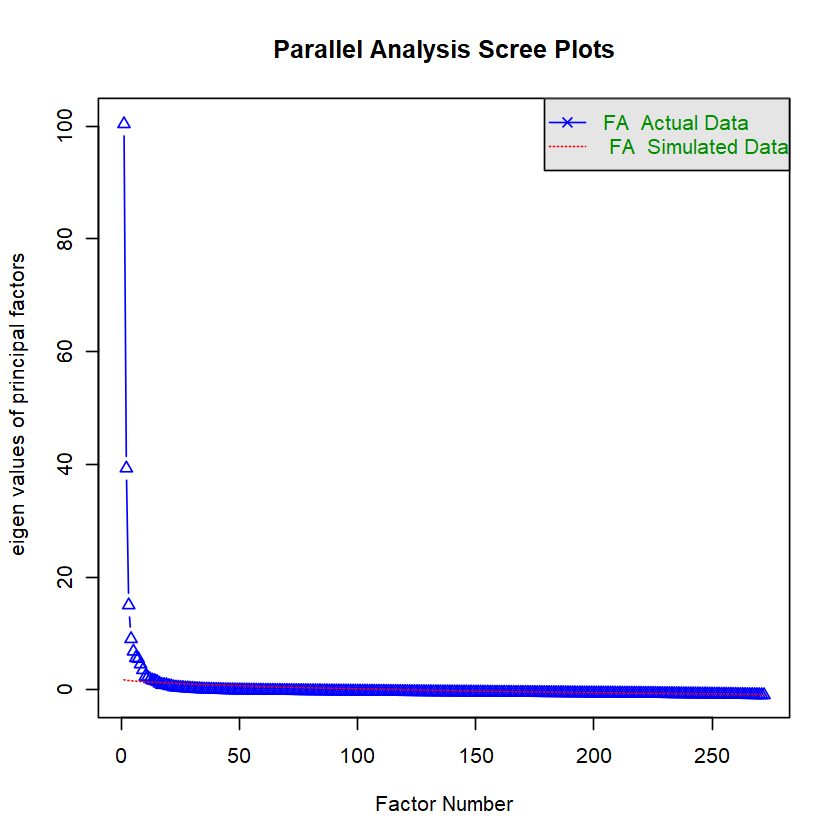

Parallel analysis suggests that the number of factors =  15  and the number of components =  NA 

ANO: 2021 

PARALLEL ANALYSIS: 2021 
Variáveis finais: 271 


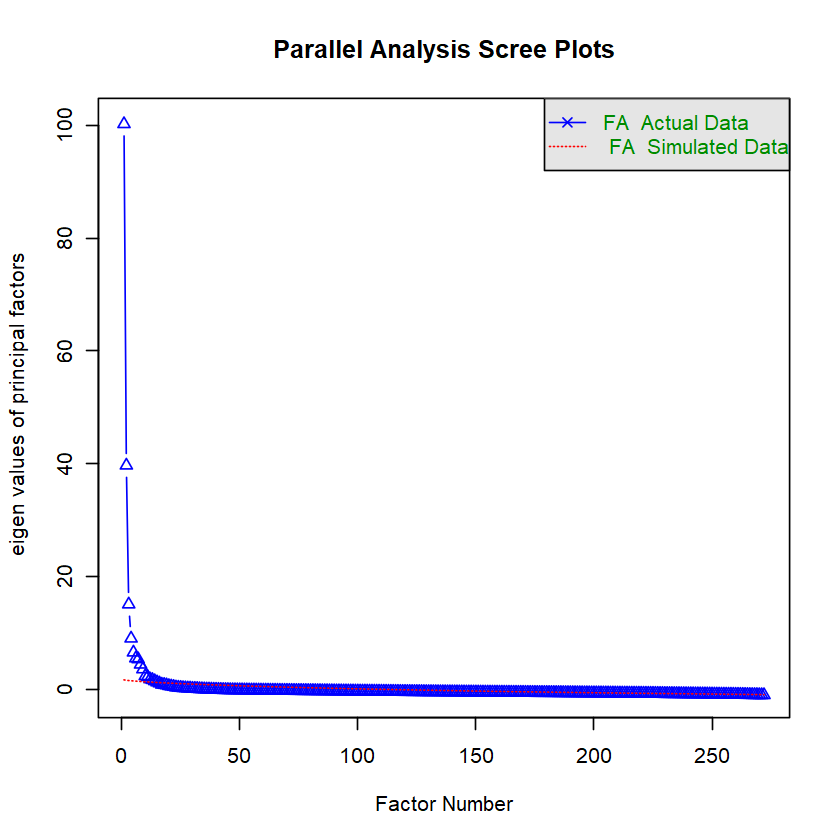

Parallel analysis suggests that the number of factors =  15  and the number of components =  NA 

ANO: 2023 

PARALLEL ANALYSIS: 2023 
Variáveis finais: 271 


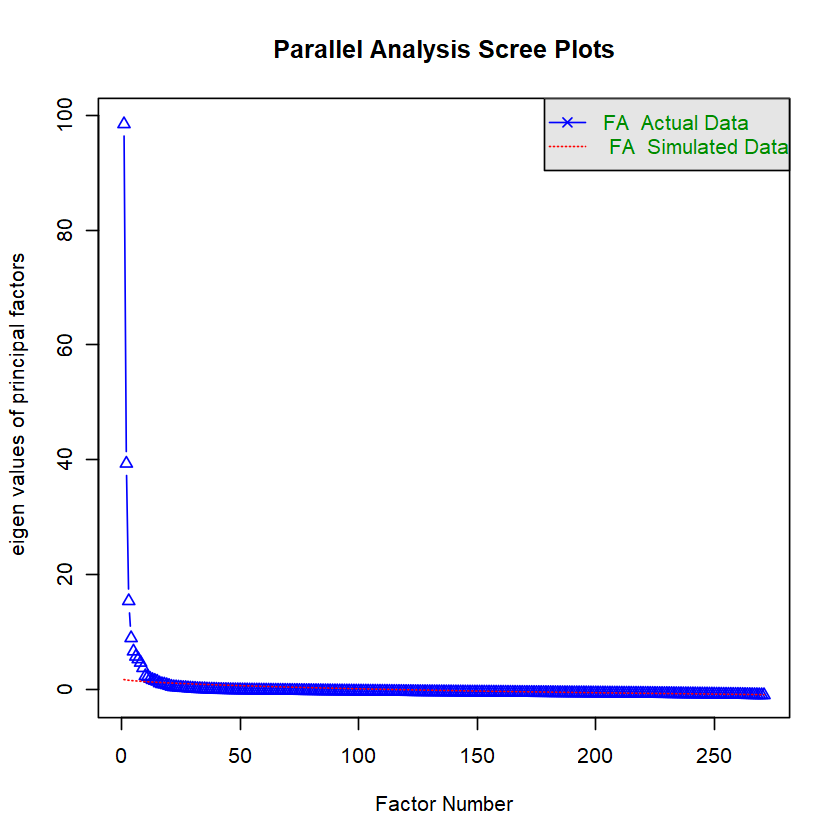

Parallel analysis suggests that the number of factors =  15  and the number of components =  NA 

ANO: 2025 

PARALLEL ANALYSIS: 2025 
Variáveis finais: 271 


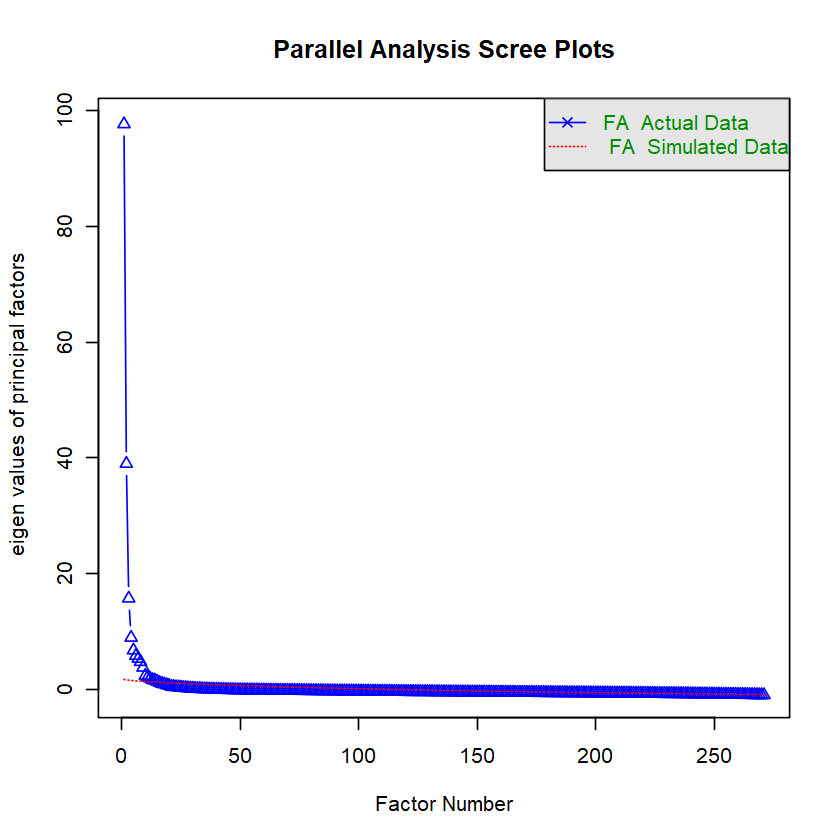

Parallel analysis suggests that the number of factors =  15  and the number of components =  NA 


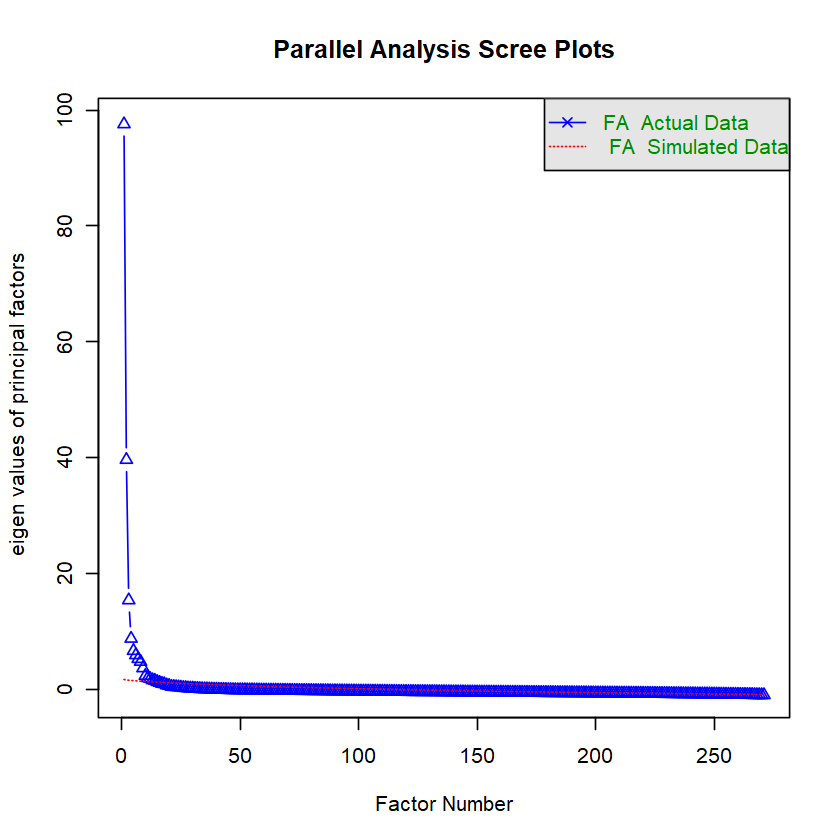

In [32]:
# =========================================================
# RODAR PARALLEL ANALYSIS POR ANO
# =========================================================

parallel_results <- list()

for(a in anos){

  cat("\nANO:", a, "\n")

  dados_ano <- efa_final[
    efa_final$Version_Year == a,
  ]

  dados_ano <- dados_ano %>%

    select(
      -`O*NET-SOC Code`,
      -Title,
      -Version_Year
    )

  parallel_results[[as.character(a)]] <-
    run_parallel(dados_ano, a)
}

In [35]:
# =========================================================
# FUNÇÃO VSS + MAP
# =========================================================

run_vss_map <- function(data, ano, max_factors = 20){

  cat("\n====================================\n")
  cat("VSS + MAP:", ano, "\n")
  cat("====================================\n")

  # -------------------------------------------------------
  # remover colunas totalmente NA
  # -------------------------------------------------------

  data <- data %>%
    select(
      where(~ !all(is.na(.)))
    )

  # -------------------------------------------------------
  # remover variância zero
  # -------------------------------------------------------

  data <- data %>%
    select(
      where(~ {
        s <- sd(., na.rm = TRUE)
        !is.na(s) && s > 0
      })
    )

  # -------------------------------------------------------
  # imputação simples
  # -------------------------------------------------------

  data <- data %>%
    mutate(
      across(
        everything(),
        ~ ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .
        )
      )
    )

  # -------------------------------------------------------
  # converter para numérico
  # -------------------------------------------------------

  data <- data %>%
    mutate(
      across(
        everything(),
        as.numeric
      )
    )

  cat("Variáveis finais:", ncol(data), "\n")

  # -------------------------------------------------------
  # matriz de correlação Spearman
  # -------------------------------------------------------

  cor_mat <- cor(
    data,
    method = "spearman",
    use = "pairwise.complete.obs"
  )

  cor_mat[!is.finite(cor_mat)] <- 0

  diag(cor_mat) <- 1

  # -------------------------------------------------------
  # VSS
  # -------------------------------------------------------

  res <- psych::VSS(
    cor_mat,
    n = 5,
    n.obs = nrow(data),
    rotate = "oblimin",
    fm = "minres",
    plot = FALSE
  )

  # -------------------------------------------------------
  # MAP
  # -------------------------------------------------------

  map_factors <- which.min(res$map)

  # -------------------------------------------------------
  # VSS
  # -------------------------------------------------------

  vss1_factors <- which.max(res$cfit.1)

  vss2_factors <- which.max(res$cfit.2)

  cat("MAP sugere:", map_factors, "fatores\n")
  cat("VSS1 sugere:", vss1_factors, "fatores\n")
  cat("VSS2 sugere:", vss2_factors, "fatores\n")

  return(res)

}

# =========================================================
# EXECUTAR PARA TODOS OS ANOS
# =========================================================

vss_results <- list()

for(a in anos){

  dados_ano <- efa_final %>%

    filter(
      Version_Year == a
    ) %>%

    select(
      -`O*NET-SOC Code`,
      -Title,
      -Version_Year
    )

  vss_results[[as.character(a)]] <-
    run_vss_map(
      dados_ano,
      a,
      max_factors = 20
    )

}

# =========================================================
# TABELA RESUMO
# =========================================================

tabela_diagnostico <- data.frame()

for(a in names(vss_results)){

  res <- vss_results[[a]]

  tabela_diagnostico <-

    rbind(

      tabela_diagnostico,

      data.frame(

        Ano = a,

        MAP_Fatores =
          which.min(res$map),

        MAP_Min =
          round(min(res$map), 4),

        VSS1_Fatores =
          which.max(res$cfit.1),

        VSS1_Max =
          round(max(res$cfit.1), 4),

        VSS2_Fatores =
          which.max(res$cfit.2),

        VSS2_Max =
          round(max(res$cfit.2), 4)

      )

    )

}


VSS + MAP: 2017 
Variáveis finais: 272 
MAP sugere: 5 fatores
VSS1 sugere: 1 fatores
VSS2 sugere: 2 fatores

VSS + MAP: 2019 
Variáveis finais: 272 
MAP sugere: 5 fatores
VSS1 sugere: 1 fatores
VSS2 sugere: 2 fatores

VSS + MAP: 2021 
Variáveis finais: 271 
MAP sugere: 5 fatores
VSS1 sugere: 1 fatores
VSS2 sugere: 2 fatores

VSS + MAP: 2023 
Variáveis finais: 271 
MAP sugere: 5 fatores
VSS1 sugere: 1 fatores
VSS2 sugere: 2 fatores

VSS + MAP: 2025 
Variáveis finais: 271 
MAP sugere: 5 fatores
VSS1 sugere: 1 fatores
VSS2 sugere: 2 fatores


   Ano MAP_Fatores MAP_Min VSS1_Fatores VSS1_Max VSS2_Fatores VSS2_Max
1 2017           5  0.0164            1   0.8217            2   0.9045
2 2019           5  0.0162            1   0.8188            2   0.9045
3 2021           5  0.0163            1   0.8145            2   0.9006
4 2023           5  0.0161            1   0.8129            2   0.8956
5 2025           5  0.0159            1   0.8103            2   0.8986


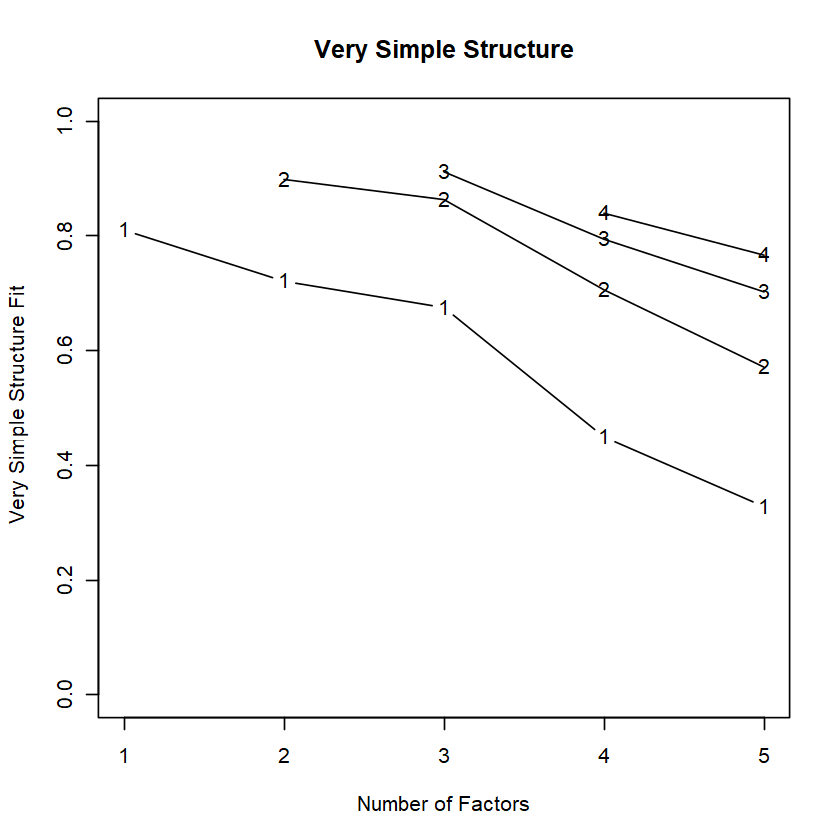

In [36]:
# =========================================================
# RESULTADO FINAL
# =========================================================

print(tabela_diagnostico)

# =========================================================
# GRÁFICO DO ÚLTIMO ANO
# =========================================================

ultimo_ano <- tail(names(vss_results), 1)

plot(
  vss_results[[ultimo_ano]],
  main = paste(
    "VSS -",
    ultimo_ano
  )
)

### Análise Fatorial Exploratória

In [ ]:
rename_onet <- c(

  "Administrative - Level" =
    "Clerical - Level",

  "Administrative - Importance" =
    "Clerical - Importance",

  "Working with Computers - Level" =
    "Interacting With Computers - Level",

  "Working with Computers - Importance" =
    "Interacting With Computers - Importance",

  "Communicating with People Outside the Organization - Level" =
    "Communicating with Persons Outside Organization - Level",

  "Communicating with People Outside the Organization - Importance" =
    "Communicating with Persons Outside Organization - Importance",

  "Inspecting Equipment, Structures, or Materials - Level" =
    "Inspecting Equipment, Structures, or Material - Level",

  "Inspecting Equipment, Structures, or Materials - Importance" =
    "Inspecting Equipment, Structures, or Material - Importance",

  "Providing Consultation and Advice to Others - Level" =
    "Provide Consultation and Advice to Others - Level",

  "Providing Consultation and Advice to Others - Importance" =
    "Provide Consultation and Advice to Others - Importance",

  "Operations Monitoring - Level" =
    "Operation Monitoring - Level",

  "Operations Monitoring - Importance" =
    "Operation Monitoring - Importance",

  "Judging the Qualities of Objects, Services, or People - Level" =
    "Judging the Qualities of Things, Services, or People - Level",

  "Judging the Qualities of Objects, Services, or People - Importance" =
    "Judging the Qualities of Things, Services, or People - Importance"
)

names(efa_final) <- recode(
  names(efa_final),
  !!!rename_onet
)

In [ ]:
efa_final <- efa_final %>% janitor::clean_names()

# encontrar variáveis comuns a todos os anos

anos <- sort(unique(efa_final$version_year))

vars_por_ano <- list()

for(a in anos){

  vars_por_ano[[as.character(a)]] <-

    efa_final %>%

    filter(version_year == a) %>%

    select(
      -o_net_soc_code,
      -title,
      -version_year
    ) %>%

    select(
      where(~ {
        s <- sd(., na.rm = TRUE)
        !is.na(s) && s > 0
      })
    ) %>%

    names()
}

vars_comuns <- Reduce(
  intersect,
  vars_por_ano
)

length(vars_comuns)

In [ ]:
parallel_results <- list()

for(a in anos){

  dados <- efa_final %>%

    filter(version_year == a) %>%

    select(
      all_of(vars_comuns)
    )

  dados <- dados %>%

    mutate(
      across(
        everything(),
        ~ ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .
        )
      )
    )

  parallel_results[[as.character(a)]] <-

    fa.parallel(

      dados,

      fa = "fa",

      fm = "minres",

      cor = "cor",

      n.iter = 100

    )

}

In [ ]:
vss_results1 <- list()

for(a in anos){

  dados <- efa_final %>%

    filter(version_year == a) %>%

    select(
      all_of(vars_comuns)
    )

  dados <- dados %>%

    mutate(
      across(
        everything(),
        ~ ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .
        )
      )
    )

  cor_mat <- cor(
    dados,
    method = "spearman"
  )

  vss_results1[[as.character(a)]] <-

    VSS(
      cor_mat,
      n = 5,
      fm = "minres",
      rotate = "oblimin",
      n.obs = nrow(dados),
      plot = FALSE
    )

}

In [ ]:
vss_report <- map_dfr(

  names(vss_results1),

  function(a){

    res <- vss_results1[[a]]

    tibble(

      Ano = as.numeric(a),

      VSS1_Fit = res$vss.stats[1,"fit"],
      VSS2_Fit = res$vss.stats[2,"fit"],
      VSS3_Fit = res$vss.stats[3,"fit"],
      VSS4_Fit = res$vss.stats[4,"fit"],
      VSS5_Fit = res$vss.stats[5,"fit"],

      MAP_Sugerido = which.min(res$map),
      MAP_Min = min(res$map)

    )

  }

)

print(vss_report)

In [ ]:
vss_long <- vss_report %>%

  pivot_longer(

    cols = starts_with("VSS"),

    names_to = "Modelo",

    values_to = "Fit"

  )

ggplot(

  vss_long,

  aes(
    x = Modelo,
    y = Fit,
    group = Ano,
    color = factor(Ano)
  )

) +

  geom_line(linewidth = 1) +

  geom_point(size = 3) +

  labs(

    title = "Very Simple Structure (1 a 5 fatores)",

    x = "Número de Fatores",

    y = "VSS Fit",

    color = "Ano"

  ) +

  theme_minimal()

In [ ]:
map_report <- map_dfr(

  names(vss_results1),

  function(a){

    tibble(

      Ano = as.numeric(a),

      Fatores = 1:length(vss_results1[[a]]$map),

      MAP = vss_results1[[a]]$map

    )

  }

)

ggplot(

  map_report,

  aes(

    x = Fatores,

    y = MAP,

    color = factor(Ano)

  )

) +

  geom_line(linewidth = 1) +

  geom_point(size = 2) +

  labs(

    title = "Velicer MAP",

    x = "Número de Fatores",

    y = "Average Partial Correlation",

    color = "Ano"

  ) +

  theme_minimal()

In [ ]:
for(a in names(vss_results1)){

  cat("\nAno:", a, "\n")

  plot(

    vss_results1[[a]],

    main = paste(
      "VSS -",
      a
    )

  )

}

In [ ]:
efa_5fatores <- list()

for(a in anos){

  dados <- efa_final %>%

    filter(version_year == a) %>%

    select(
      all_of(vars_comuns)
    )

  dados <- dados %>%

    mutate(
      across(
        everything(),
        ~ ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .
        )
      )
    )

  cor_mat <- cor(
    dados,
    method = "spearman"
  )

  efa_5fatores[[as.character(a)]] <-

    fa(

      cor_mat,

      nfactors = 5,

      rotate = "oblimin",

      fm = "minres",

      n.obs = nrow(dados)

    )
}

In [ ]:
comparacoes <- data.frame()

for(i in 1:(length(anos)-1)){

  a1 <- as.character(anos[i])
  a2 <- as.character(anos[i+1])

  cong <- factor.congruence(
    efa_5fatores[[a1]],
    efa_5fatores[[a2]]
  )

  comparacoes <- rbind(

    comparacoes,

    data.frame(

      Ano1 = a1,

      Ano2 = a2,

      Congruencia_Media =
        mean(
          apply(abs(cong),1,max)
        )

    )
  )
}

comparacoes

In [ ]:
loadings_2017 <- as.data.frame(
  unclass(efa_5fatores[["2017"]]$loadings)
)

loadings_2025 <- as.data.frame(
  unclass(efa_5fatores[["2025"]]$loadings)
)

In [ ]:
factor.congruence(
  efa_5fatores[["2017"]],
  efa_5fatores[["2019"]]
)

factor.congruence(
  efa_5fatores[["2019"]],
  efa_5fatores[["2021"]]
)

factor.congruence(
  efa_5fatores[["2021"]],
  efa_5fatores[["2023"]]
)

factor.congruence(
  efa_5fatores[["2023"]],
  efa_5fatores[["2025"]]
)

In [ ]:
segunda_ordem <- list()

for(a in anos){

  segunda_ordem[[as.character(a)]] <-

    fa(

      efa_5fatores[[as.character(a)]]$Phi,

      nfactors = 2,

      rotate = "oblimin",

      fm = "minres"

    )

}

In [ ]:
scores_longitudinais <- list()

for(a in anos){

  dados <- efa_final %>%

    filter(version_year == a)

  vars <- vars_comuns

  scores <- factor.scores(

    dados[, vars],

    efa_5fatores[[as.character(a)]],

    method = "tenBerge"

  )

  scores_longitudinais[[as.character(a)]] <-

    bind_cols(

      dados,

      as.data.frame(scores$scores)

    )
}

In [ ]:
for(a in names(segunda_ordem)){

  cat("\n========================\n")
  cat("ANO:", a, "\n")
  cat("========================\n")

  print(
    segunda_ordem[[a]]$loadings,
    cutoff = 0.30
  )

}

In [ ]:
efa_5fatores[["2025"]]$Phi

In [ ]:
for(a in names(efa_5fatores)){

  cat("\nANO:", a, "\n")

  print(
    round(
      efa_5fatores[[a]]$Phi,
      3
    )
  )

}

In [ ]:
scores_longitudinais[["2025"]] %>%

  select(starts_with("MR")) %>%

  summary()

In [ ]:
scores_longitudinais[["2025"]] %>%

  ggplot(
    aes(MR1)
  ) +

  geom_histogram(
    bins = 30
  ) +

  theme_minimal()

In [ ]:
media_scores <- map_dfr(

  names(scores_longitudinais),

  function(a){

    scores_longitudinais[[a]] %>%

      summarise(

        F1 = mean(MR1, na.rm = TRUE),
        F2 = mean(MR2, na.rm = TRUE),
        F3 = mean(MR3, na.rm = TRUE),
        F4 = mean(MR4, na.rm = TRUE),
        F5 = mean(MR5, na.rm = TRUE)

      ) %>%

      mutate(
        Ano = as.numeric(a)
      )

  }

)

media_scores

In [ ]:
media_scores_long <- media_scores %>%

  pivot_longer(

    F1:F5,

    names_to = "Fator",

    values_to = "Media"

  )

ggplot(

  media_scores_long,

  aes(

    Ano,

    Media,

    color = Fator

  )

) +

  geom_line(
    linewidth = 1
  ) +

  geom_point(
    size = 3
  ) +

  theme_minimal()

In [ ]:
for(a in names(segunda_ordem)){

  cat("\nANO:", a, "\n")

  print(
    segunda_ordem[[a]]$loadings,
    cutoff = 0.20
  )

}

In [ ]:
fa.sort(
  efa_5fatores[["2025"]]
)

In [ ]:
scores_longitudinais[["2025"]] |>
  select(MR1, MR2, MR3, MR4, MR5) |>
  summary()

In [ ]:
for(i in 1:5){

  cat("\n\n====================\n")
  cat("FATOR", i, "\n")
  cat("====================\n")

  cargas <- efa_5fatores[["2025"]]$loadings[,i]

  top <- sort(abs(cargas), decreasing = TRUE)

  print(
    round(
      cargas[names(top)[1:20]],
      3
    )
  )

}

### Análise Fatorial Confirmatória

In [ ]:
loadings_2025 <- as.data.frame(
  unclass(efa_5fatores[["2025"]]$loadings)
)

In [ ]:
itens_fator <- list()

for(f in colnames(loadings_2025)){

  itens_fator[[f]] <-

    loadings_2025 %>%

    mutate(item = rownames(loadings_2025)) %>%

    arrange(desc(abs(.data[[f]]))) %>%

    slice(1:10) %>%

    pull(item)

}

In [ ]:
itens_fator

In [ ]:
modelo_cfa <- paste0(
  "MR2 =~ ", paste0("`", itens_fator$MR2, "`", collapse = " + "), "\n",
  "MR3 =~ ", paste0("`", itens_fator$MR3, "`", collapse = " + "), "\n",
  "MR5 =~ ", paste0("`", itens_fator$MR5, "`", collapse = " + "), "\n",
  "MR4 =~ ", paste0("`", itens_fator$MR4, "`", collapse = " + "), "\n",
  "MR1 =~ ", paste0("`", itens_fator$MR1, "`", collapse = " + ")
)

cat(modelo_cfa)

In [ ]:
dados_cfa <- dados %>%
  clean_names()

In [ ]:
clean_name <- function(x){

  x <- tolower(x)

  x <- gsub(" - ", "_", x)
  x <- gsub(",", "", x)
  x <- gsub("/", "_", x)
  x <- gsub("\\(", "", x)
  x <- gsub("\\)", "", x)
  x <- gsub(" ", "_", x)

  x
}

In [ ]:
itens_fator_limpo <- lapply(
  itens_fator,
  clean_name
)

In [ ]:
head(itens_fator_limpo$MR2)

In [ ]:
vars_modelo <- unlist(itens_fator_limpo)

setdiff(
  vars_modelo,
  names(dados_cfa)
)

In [ ]:
fit <- lavaan::cfa(
  modelo_cfa,
  data = dados_cfa,
  estimator = "MLR",
  std.lv = TRUE,
  missing = "fiml"
)

In [ ]:
fitMeasures(
  fit,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower",
  "rmsea.ci.upper","srmr")
)

In [ ]:
compRelSEM(fit)

In [ ]:
AVE(fit)

In [ ]:
sqrt(AVE(fit))

In [ ]:
inspect(fit, "std")$lambda

In [ ]:
standardizedSolution(fit)

In [ ]:
standardizedSolution(fit) |>
  dplyr::filter(op == "=~") |>
  dplyr::arrange(est.std)

### Análise FAtorial Confirmatória 2.0

In [ ]:
modelo_5f <- '

Fisico =~
response_orientation_level +
multilimb_coordination_level +
depth_perception_level +
reaction_time_level +
performing_general_physical_activities_level +
static_strength_level +
gross_body_equilibrium_level +
operation_and_control_level +
operating_vehicles_mechanized_devices_or_equipment_importance +
repairing_and_maintaining_mechanical_equipment_importance

Gestao =~
training_and_teaching_others_level +
training_and_teaching_others_importance +
interpreting_the_meaning_of_information_for_others_level +
developing_objectives_and_strategies_level +
coaching_and_developing_others_level +
interpreting_the_meaning_of_information_for_others_importance +
developing_objectives_and_strategies_importance +
coaching_and_developing_others_importance +
scheduling_work_and_activities_level +
guiding_directing_and_motivating_subordinates_level

Cognitivo =~
speed_of_closure_level +
flexibility_of_closure_level +
speed_of_closure_importance +
flexibility_of_closure_importance +
perceptual_speed_level +
problem_sensitivity_level +
problem_sensitivity_importance +
information_ordering_importance +
information_ordering_level +
perceptual_speed_importance

Negocios =~
management_of_financial_resources_level +
management_of_financial_resources_importance +
management_of_material_resources_level +
management_of_material_resources_importance +
administration_and_management_importance +
selling_or_influencing_others_level

Social =~
assisting_and_caring_for_others_importance +
assisting_and_caring_for_others_level +
therapy_and_counseling_importance +
therapy_and_counseling_level +
psychology_importance +
performing_for_or_working_directly_with_the_public_importance

'

In [ ]:
modelo_6f <- '

MR2 =~
response_orientation_level +
multilimb_coordination_level +
depth_perception_level +
reaction_time_level +
performing_general_physical_activities_level +
static_strength_level +
gross_body_equilibrium_level +
operation_and_control_level +
operating_vehicles_mechanized_devices_or_equipment_importance +
repairing_and_maintaining_mechanical_equipment_importance

MR3 =~
training_and_teaching_others_level +
training_and_teaching_others_importance +
interpreting_the_meaning_of_information_for_others_level +
developing_objectives_and_strategies_level +
coaching_and_developing_others_level +
interpreting_the_meaning_of_information_for_others_importance +
developing_objectives_and_strategies_importance +
coaching_and_developing_others_importance +
scheduling_work_and_activities_level +
guiding_directing_and_motivating_subordinates_level

Cognitivo =~
speed_of_closure_level +
flexibility_of_closure_level +
speed_of_closure_importance +
flexibility_of_closure_importance +
perceptual_speed_level +
problem_sensitivity_level +
problem_sensitivity_importance +
information_ordering_importance +
information_ordering_level +
perceptual_speed_importance

Negocios =~
management_of_financial_resources_level +
management_of_financial_resources_importance +
management_of_material_resources_level +
management_of_material_resources_importance +
administration_and_management_importance +
selling_or_influencing_others_level

Assistencial =~
assisting_and_caring_for_others_importance +
assisting_and_caring_for_others_level +
therapy_and_counseling_importance +
therapy_and_counseling_level +
psychology_importance +
performing_for_or_working_directly_with_the_public_importance

TecnicoCriativo =~
design_importance +
design_level +
engineering_and_technology_importance +
engineering_and_technology_level

'

In [ ]:
modelo_2ord <- '

Fisico =~
response_orientation_level +
multilimb_coordination_level +
depth_perception_level +
reaction_time_level +
performing_general_physical_activities_level +
static_strength_level +
gross_body_equilibrium_level +
operation_and_control_level

Gestao =~
training_and_teaching_others_level +
training_and_teaching_others_importance +
developing_objectives_and_strategies_level +
coaching_and_developing_others_level +
guiding_directing_and_motivating_subordinates_level

Cognitivo =~
speed_of_closure_level +
flexibility_of_closure_level +
problem_sensitivity_level +
information_ordering_level +
perceptual_speed_level

Negocios =~
management_of_financial_resources_level +
management_of_material_resources_level +
administration_and_management_importance +
management_of_financial_resources_importance +
management_of_material_resources_importance

Social =~
assisting_and_caring_for_others_importance +
assisting_and_caring_for_others_level +
therapy_and_counseling_importance +
therapy_and_counseling_level +
psychology_importance

CompetenciaIntelectual =~
Gestao +
Cognitivo +
Negocios

'

In [ ]:
modelo_bifactor <- '

Geral =~

response_orientation_level +
multilimb_coordination_level +
depth_perception_level +
reaction_time_level +

training_and_teaching_others_level +
developing_objectives_and_strategies_level +
coaching_and_developing_others_level +

speed_of_closure_level +
flexibility_of_closure_level +
problem_sensitivity_level +

management_of_financial_resources_level +
management_of_material_resources_level +
administration_and_management_importance +

assisting_and_caring_for_others_importance +
therapy_and_counseling_importance +
psychology_importance


Fisico =~
response_orientation_level +
multilimb_coordination_level +
depth_perception_level +
reaction_time_level

Gestao =~
training_and_teaching_others_level +
developing_objectives_and_strategies_level +
coaching_and_developing_others_level

Cognitivo =~
speed_of_closure_level +
flexibility_of_closure_level +
problem_sensitivity_level

Negocios =~
management_of_financial_resources_level +
management_of_material_resources_level +
administration_and_management_importance

Social =~
assisting_and_caring_for_others_importance +
therapy_and_counseling_importance +
psychology_importance


Geral ~~ 0*Fisico
Geral ~~ 0*Gestao
Geral ~~ 0*Cognitivo
Geral ~~ 0*Negocios
Geral ~~ 0*Social

Fisico ~~ 0*Gestao
Fisico ~~ 0*Cognitivo
Fisico ~~ 0*Negocios
Fisico ~~ 0*Social

Gestao ~~ 0*Cognitivo
Gestao ~~ 0*Negocios
Gestao ~~ 0*Social

Cognitivo ~~ 0*Negocios
Cognitivo ~~ 0*Social

Negocios ~~ 0*Social

'

In [ ]:
fit5 <- cfa(
  modelo_5f,
  data = dados_cfa,
  estimator = "MLR",
  std.lv = TRUE,
  missing = "fiml"
)

fit6 <- cfa(
  modelo_6f,
  data = dados_cfa,
  estimator = "MLR",
  std.lv = TRUE,
  missing = "fiml"
)

fit2ord <- cfa(
  modelo_2ord,
  data = dados_cfa,
  estimator = "MLR",
  std.lv = TRUE,
  missing = "fiml"
)

fit_bi <- cfa(
  modelo_bifactor,
  data = dados_cfa,
  estimator = "MLR",
  std.lv = TRUE,
  missing = "fiml"
)

In [ ]:
print('Modelo de 5 Fatores')
fitMeasures(
  fit5,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower",
  "rmsea.ci.upper","srmr")
)

print('Modelo de 6 Fatores')
fitMeasures(
  fit6,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower",
  "rmsea.ci.upper","srmr")
)

print('Modelo de Segunda Ordem')
fitMeasures(
  fit2ord,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower",
  "rmsea.ci.upper","srmr")
)

print('Modelo de Bifator')
fitMeasures(
  fit_bi,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower",
  "rmsea.ci.upper","srmr")
)

In [ ]:
sapply(
  list(
    fit5 = fit5,
    fit6 = fit6,
    fit2ord = fit2ord,
    fit_bi = fit_bi
  ),
  fitMeasures,
  c(
    "cfi",
    "tli",
    "rmsea",
    "srmr",
    "aic",
    "bic"
  )
)

In [ ]:
print('CR')
compRelSEM(fit_bi)

In [ ]:
bifactorIndices(fit_bi)

In [ ]:
modelo_4f <- '

Fisico =~
response_orientation_level +
multilimb_coordination_level +
depth_perception_level +
reaction_time_level +
performing_general_physical_activities_level +
static_strength_level +
gross_body_equilibrium_level +
operation_and_control_level

Cognitivo =~
speed_of_closure_level +
flexibility_of_closure_level +
problem_sensitivity_level +
information_ordering_level +
developing_objectives_and_strategies_level +
interpreting_the_meaning_of_information_for_others_level +
making_decisions_and_solving_problems_level +
critical_thinking_level

Negocios =~
management_of_financial_resources_level +
management_of_material_resources_level +
administration_and_management_importance +
sales_and_marketing_level +
selling_or_influencing_others_level +
guiding_directing_and_motivating_subordinates_level +
scheduling_work_and_activities_level

Social =~
assisting_and_caring_for_others_level +
therapy_and_counseling_level +
psychology_importance +
coaching_and_developing_others_level +
training_and_teaching_others_level +
performing_for_or_working_directly_with_the_public_importance

'

In [ ]:
modelo_2ordem <- '

Fisico =~
response_orientation_level +
multilimb_coordination_level +
depth_perception_level +
reaction_time_level +
performing_general_physical_activities_level +
static_strength_level +
gross_body_equilibrium_level +
operation_and_control_level

Cognitivo =~
speed_of_closure_level +
flexibility_of_closure_level +
problem_sensitivity_level +
information_ordering_level +
developing_objectives_and_strategies_level +
interpreting_the_meaning_of_information_for_others_level +
making_decisions_and_solving_problems_level +
critical_thinking_level

Negocios =~
management_of_financial_resources_level +
management_of_material_resources_level +
administration_and_management_importance +
sales_and_marketing_level +
selling_or_influencing_others_level +
guiding_directing_and_motivating_subordinates_level +
scheduling_work_and_activities_level

Social =~
assisting_and_caring_for_others_level +
therapy_and_counseling_level +
psychology_importance +
coaching_and_developing_others_level +
training_and_teaching_others_level +
performing_for_or_working_directly_with_the_public_importance

SocioCognitivo =~
Cognitivo +
Negocios +
Social

'

In [ ]:
modelo_2f <- '

Fisico =~
response_orientation_level +
multilimb_coordination_level +
depth_perception_level +
reaction_time_level +
performing_general_physical_activities_level +
static_strength_level +
gross_body_equilibrium_level +
operation_and_control_level

SocioCognitivo =~
speed_of_closure_level +
flexibility_of_closure_level +
problem_sensitivity_level +
information_ordering_level +
developing_objectives_and_strategies_level +
interpreting_the_meaning_of_information_for_others_level +
making_decisions_and_solving_problems_level +
critical_thinking_level +
management_of_financial_resources_level +
management_of_material_resources_level +
administration_and_management_importance +
sales_and_marketing_level +
selling_or_influencing_others_level +
guiding_directing_and_motivating_subordinates_level +
scheduling_work_and_activities_level +
assisting_and_caring_for_others_level +
therapy_and_counseling_level +
psychology_importance +
coaching_and_developing_others_level +
training_and_teaching_others_level +
performing_for_or_working_directly_with_the_public_importance

'

In [ ]:
fit4 <- cfa(
  modelo_4f,
  data = dados_cfa,
  estimator = "MLR",
  std.lv = TRUE,
  missing = "fiml"
)

fit2ordem <- cfa(
  modelo_2ordem,
  data = dados_cfa,
  estimator = "MLR",
  std.lv = TRUE,
  missing = "fiml"
)

fit2 <- cfa(
  modelo_2f,
  data = dados_cfa,
  estimator = "MLR",
  std.lv = TRUE,
  missing = "fiml"
)

In [ ]:
sapply(
  list(
    fit4 = fit4,
    fit2ordem = fit2ordem,
    fit2 = fit2
  ),
  fitMeasures,
  c(
    "cfi",
    "tli",
    "rmsea",
    "srmr",
    "aic",
    "bic"
  )
)

In [ ]:
print('Modelo de 4 Fatores')
fitMeasures(
  fit4,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower",
  "rmsea.ci.upper","srmr")
)

print('Modelo de Segunda Ordem')
fitMeasures(
  fit2ordem,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower",
  "rmsea.ci.upper","srmr")
)

print('Modelo de 2 Fatores')
fitMeasures(
  fit2,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower",
  "rmsea.ci.upper","srmr")
)

In [ ]:
comparacao <- rbind(

  cbind(
    modelo = "5 fatores",
    fitMeasures(
      fit5,
      c("cfi","tli","rmsea","srmr","aic","bic")
    )
  ),

  cbind(
    modelo = "4 fatores",
    fitMeasures(
      fit4,
      c("cfi","tli","rmsea","srmr","aic","bic")
    )
  ),

  cbind(
    modelo = "2 ordem",
    fitMeasures(
      fit2ordem,
      c("cfi","tli","rmsea","srmr","aic","bic")
    )
  ),

  cbind(
    modelo = "2 fatores",
    fitMeasures(
      fit2,
      c("cfi","tli","rmsea","srmr","aic","bic")
    )
  )

)

comparacao

In [ ]:
cargas <- standardizedSolution(fit) %>%
  filter(op == "=~") %>%
  select(
    fator = lhs,
    item = rhs,
    carga = est.std,
    pvalue
  ) %>%
  arrange(fator, desc(abs(carga)))

cargas

In [ ]:
itens_removidos <- cargas %>%
  filter(abs(carga) < 0.70)

itens_removidos

In [ ]:
itens_mantidos <- cargas %>%
  filter(abs(carga) >= 0.70)

itens_mantidos %>%
  group_by(fator) %>%
  summarise(
    mantidos = n()
  )

In [ ]:
relatorio <- cargas %>%
  mutate(
    status = ifelse(abs(carga) >= 0.70,
                    "MANTER",
                    "REMOVER")
  ) %>%
  arrange(fator, desc(abs(carga)))

relatorio

In [ ]:
itens_finais <- cargas %>%
  filter(abs(carga) >= 0.70)

In [ ]:
modelo_refinado <- itens_finais %>%
  group_by(fator) %>%
  summarise(
    sintaxe = paste(item, collapse = " + ")
  ) %>%
  mutate(
    linha = paste0(fator, " =~ ", sintaxe)
  ) %>%
  pull(linha) %>%
  paste(collapse = "\n")

cat(modelo_refinado)

In [ ]:
fit_refinado <- cfa(
  modelo_refinado,
  data = dados_cfa,
  estimator = "MLR",
  std.lv = TRUE,
  missing = "fiml"
)

In [ ]:
comparacao <- rbind(

  Original = fitMeasures(
    fit,
    c("cfi","tli","rmsea","srmr","aic","bic")
  ),

  Refinado = fitMeasures(
    fit_refinado,
    c("cfi","tli","rmsea","srmr","aic","bic")
  ),

  Bifator = fitMeasures(
    fit_bi,
    c("cfi","tli","rmsea","srmr","aic","bic")
  )

)

round(comparacao, 3)

In [ ]:
itens_finais %>%
  count(fator)

In [ ]:
lavInspect(
  fit_refinado,
  "cor.lv"
)

In [ ]:
modindices(fit_refinado, minimum.value = 20)